# ClinVar Extraction and Audit

In [1]:
import pandas as pd
from pathlib import Path

repo = "https://raw.githubusercontent.com/Joshua-Pillai/NephVar/main/CGN"
genes = ["C3","CD46","CFH","CFHR5","CFI","COL4A3","COL4A4","COL4A5","COL4A6","FN1"]
out = Path("/content/cgn_csv"); out.mkdir(parents=True, exist_ok=True)

total = 0
for g in genes:
    df = pd.read_csv(f"{repo}/{g}.txt", sep="\t", low_memory=False)
    df.to_csv(out / f"{g}.csv", index=False)
    print(f"{g}: {len(df)} variants")
    total += len(df)

print(f"\nTotal: {total:,} variants across {len(genes)} genes")

df = pd.read_csv(out / "C3.csv", low_memory=False)
print(f"C3.csv: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.columns.tolist())

C3: 1751 variants
CD46: 562 variants
CFH: 1523 variants
CFHR5: 352 variants
CFI: 770 variants
COL4A3: 3186 variants
COL4A4: 3481 variants
COL4A5: 3264 variants
COL4A6: 861 variants
FN1: 1900 variants

Total: 17,650 variants across 10 genes
C3.csv: 1751 rows, 25 columns
['Name', 'Gene(s)', 'Protein change', 'Condition(s)', 'Accession', 'GRCh37Chromosome', 'GRCh37Location', 'GRCh38Chromosome', 'GRCh38Location', 'VariationID', 'AlleleID(s)', 'dbSNP ID', 'Canonical SPDI', 'Variant type', 'Molecular consequence', 'Germline classification', 'Germline date last evaluated', 'Germline review status', 'Somatic clinical impact', 'Somatic clinical impact date last evaluated', 'Somatic clinical impact review status', 'Oncogenicity classification', 'Oncogenicity date last evaluated', 'Oncogenicity review status', 'Unnamed: 24']


In [2]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/cgn_csv")
genes = ["C3","CD46","CFH","CFHR5","CFI","COL4A3","COL4A4","COL4A5","COL4A6","FN1"]

frames = [pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g) for g in genes]
cgn = pd.concat(frames, ignore_index=True)

# Counts
print(f"Total rows:     {len(cgn):>7,}")
print(f"Unique IDs:     {cgn['VariationID'].nunique():>7,}")
print(f"Duplicate rows: {len(cgn) - cgn['VariationID'].nunique():>7,}")

# Across-file duplicates
dup_vids = cgn["VariationID"].value_counts().loc[lambda x: x > 1]
dup_rows = cgn[cgn["VariationID"].isin(dup_vids.index)]
overlap = dup_rows.groupby("VariationID")["source"].apply(lambda s: " + ".join(sorted(s.unique())))

print(f"\nVariants in >1 file: {len(dup_vids)}")
print("\nOverlap patterns:")
print(overlap.value_counts().to_string())

# Variant types among duplicates
unique_dups = dup_rows.drop_duplicates("VariationID")
print(f"\nVariant types ({len(unique_dups)} unique duplicated variants):")
print(unique_dups["Variant type"].value_counts().to_string())

# Non-CNV duplicates (the interesting ones)
cnv = {"copy number gain","copy number loss","Deletion","Duplication"}
non_cnv = unique_dups[~unique_dups["Variant type"].isin(cnv)]
if len(non_cnv) > 0:
    print(f"\nNon-CNV duplicates ({len(non_cnv)}):")
    print(non_cnv[["VariationID","Name","Variant type","Germline classification"]].to_string(index=False))

# Save report
dup_rows.sort_values(["VariationID","source"]).to_csv("/content/cgn_duplicate_report.csv", index=False)

Total rows:      17,650
Unique IDs:      17,396
Duplicate rows:     254

Variants in >1 file: 233

Overlap patterns:
source
COL4A5 + COL4A6          175
COL4A3 + COL4A4           21
CFH + CFHR5               16
COL4A3 + COL4A4 + FN1     12
CD46 + CFH + CFHR5         9

Variant types (233 unique duplicated variants):
Variant type
copy number loss             105
copy number gain             102
Deletion                      15
Duplication                    8
single nucleotide variant      2
Indel                          1

Non-CNV duplicates (3):
 VariationID                                              Name              Variant type      Germline classification
     4081614            NM_000091.5(COL4A3):c.3G>A (p.Met1Ile) single nucleotide variant Pathogenic/Likely pathogenic
      334745                     NM_000092.4(COL4A4):c.-408G>A single nucleotide variant       Uncertain significance
      545551 NC_000023.10:g.36649710_136649711del100000002insG                     Indel    

In [3]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/cgn_csv")
genes = ["C3","CD46","CFH","CFHR5","CFI","COL4A3","COL4A4","COL4A5","COL4A6","FN1"]

# Load and concatenate all 10 gene files
frames = [pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g) for g in genes]
cgn = pd.concat(frames, ignore_index=True)

# Identify VariationIDs appearing in >1 gene file
vid_counts = cgn["VariationID"].value_counts()
dup_vids = vid_counts[vid_counts > 1].index

# Split into two datasets
single_gene = cgn[~cgn["VariationID"].isin(dup_vids)].reset_index(drop=True)
multi_gene = cgn[cgn["VariationID"].isin(dup_vids)].sort_values(["VariationID", "source"]).reset_index(drop=True)

# For the multi-gene file, collapse to one row per variant with the gene list
multi_gene_collapsed = (multi_gene
    .groupby("VariationID")
    .agg({
        "source": lambda s: " + ".join(sorted(s.unique())),
        "Name": "first",
        "Gene(s)": "first",
        "Variant type": "first",
        "Molecular consequence": "first",
        "Germline classification": "first",
        "Germline date last evaluated": "first",
        "Germline review status": "first",
    })
    .rename(columns={"source": "appears_in_gene_files"})
    .reset_index())

# Save single-gene and multi-gene files separately (kept for audit trail)
single_gene.to_csv("/content/cgn_single_gene.csv", index=False)
multi_gene_collapsed.to_csv("/content/cgn_multi_gene.csv", index=False)

# ── KEY FIX: combine into one full dataset for downstream use ────────────────
cgn_full = pd.concat([single_gene, multi_gene_collapsed], ignore_index=True)
cgn_full.to_csv("/content/cgn_full.csv", index=False)

# Report
print(f"Original total rows:        {len(cgn):>7,}")
print(f"Single-gene variants:       {len(single_gene):>7,}  → cgn_single_gene.csv")
print(f"Multi-gene variants:        {len(multi_gene_collapsed):>7,}  → cgn_multi_gene.csv")
print(f"Combined (full) dataset:    {len(cgn_full):>7,}  → cgn_full.csv  ← use this downstream")
print(f"\nReconciliation:")
print(f"  {len(single_gene):,} + {len(multi_gene):,} (raw multi-gene rows) = {len(single_gene) + len(multi_gene):,}")
print(f"  {len(single_gene):,} + {len(multi_gene_collapsed):,} (unique multi-gene variants) = {len(cgn_full):,} unique variants total")

Original total rows:         17,650
Single-gene variants:        17,163  → cgn_single_gene.csv
Multi-gene variants:            233  → cgn_multi_gene.csv
Combined (full) dataset:     17,396  → cgn_full.csv  ← use this downstream

Reconciliation:
  17,163 + 487 (raw multi-gene rows) = 17,650
  17,163 + 233 (unique multi-gene variants) = 17,396 unique variants total


# Variant types

In [4]:
import pandas as pd

df = pd.read_csv("/content/cgn_single_gene.csv", low_memory=False)
print(f"Total variants: {len(df):,}\n")

# Variant type (DNA-level)
print("Variant type distribution:")
vt = df["Variant type"].value_counts(dropna=False)
vt_pct = (vt / len(df) * 100).round(2)
print(pd.DataFrame({"count": vt, "percent": vt_pct}).to_string())

# Molecular consequence (functional effect)
print("\nMolecular consequence (top 15):")
mc = df["Molecular consequence"].value_counts(dropna=False).head(15)
mc_pct = (mc / len(df) * 100).round(2)
print(pd.DataFrame({"count": mc, "percent": mc_pct}).to_string())

# Per-gene variant type breakdown
print("\nVariant type by gene:")
print(pd.crosstab(df["source"], df["Variant type"]).to_string())

Total variants: 17,163

Variant type distribution:
                           count  percent
Variant type                             
single nucleotide variant  15117    88.08
Deletion                    1134     6.61
Duplication                  447     2.60
Microsatellite               189     1.10
Indel                        119     0.69
Insertion                     70     0.41
copy number gain              48     0.28
copy number loss              22     0.13
Inversion                      8     0.05
Haplotype                      5     0.03
Variation                      3     0.02
Complex                        1     0.01

Molecular consequence (top 15):
                                                               count  percent
Molecular consequence                                                        
missense variant                                                6500    37.87
intron variant                                                  4090    23.83
synonymous varia

In [5]:
df = pd.read_csv("/content/cgn_single_gene.csv", low_memory=False)
complex_var = df[df["Variant type"] == "Complex"]
print(complex_var[["VariationID", "Name", "Gene(s)", "Variant type",
                   "Molecular consequence", "Germline classification"]].to_string(index=False))

 VariationID          Name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [6]:
df = pd.read_csv("/content/cgn_single_gene.csv", low_memory=False)

missense = df[df["Molecular consequence"].str.contains("missense", case=False, na=False)]

print(f"Total missense variants: {len(missense):,}\n")

# Crosstab: rows = ClinVar label, columns = gene
ct = pd.crosstab(missense["Germline classification"], missense["source"], margins=True, margins_name="Total")
print(ct.to_string())

Total missense variants: 7,092

source                                                C3  CD46  CFH  CFHR5  CFI  COL4A3  COL4A4  COL4A5  COL4A6  FN1  Total
Germline classification                                                                                                    
Benign                                                 0     0    1      0    2      11       8      17       8   12     59
Benign/Likely benign                                   4     2   12      8    6       9      11      17       8   14     91
Likely benign                                          4     4    4     13    9      36      31      78      17   56    252
Likely pathogenic                                      9     5   19      0   16     273     237     414       4   11    988
Likely pathogenic, low penetrance                      0     1   25      0   31       0       0       0       0    0     57
Likely pathogenic/Likely pathogenic, low penetrance    0     0    1      0    0       0       0     

# Variant histories

In [7]:
import pandas as pd
import gzip
import urllib.request
from pathlib import Path

# Load the CGN variant list (these are our keys)
cgn = pd.read_csv("/content/cgn_single_gene.csv", low_memory=False)
target_ids = set(cgn["VariationID"].astype(str))
print(f"Targeting {len(target_ids):,} CGN VariationIDs")

# Download submission_summary.txt.gz (NCBI FTP)
url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/submission_summary.txt.gz"
local = Path("/content/submission_summary.txt.gz")
if not local.exists():
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, local)
    print(f"  Saved: {local.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Using cached file: {local.stat().st_size / 1e6:.1f} MB")

# Stream-filter: read line-by-line, keep only rows matching our VariationIDs
matched_rows = []
header_line = None
n_total = 0

with gzip.open(local, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("##"):           # metadata header lines
            continue
        if line.startswith("#"):            # column header
            header_line = line.lstrip("#").strip().split("\t")
            continue
        n_total += 1
        cols = line.rstrip("\n").split("\t")
        if cols[0] in target_ids:           # VariationID is the first column
            matched_rows.append(cols)

print(f"\nScanned {n_total:,} submission records")
print(f"Matched to CGN variants: {len(matched_rows):,}")

# Build the dataframe
history = pd.DataFrame(matched_rows, columns=header_line)
history["VariationID"] = history["VariationID"].astype(int)

# Save
history.to_csv("/content/cgn_submission_history.csv", index=False)
print(f"\nSaved: /content/cgn_submission_history.csv")
print(f"  {len(history):,} submissions across {history['VariationID'].nunique():,} variants")

# Quick sanity check: how many CGN variants got at least one submission?
matched_variants = set(history["VariationID"].unique())
unmatched = set(cgn["VariationID"]) - matched_variants
print(f"  Variants with submissions: {len(matched_variants):,} / {len(cgn):,}")
print(f"  Variants with NO submissions: {len(unmatched):,}  (unexpected if any)")

Targeting 17,163 CGN VariationIDs
  Saved: 382.4 MB

Scanned 6,367,607 submission records
Matched to CGN variants: 25,997

Saved: /content/cgn_submission_history.csv
  25,997 submissions across 17,161 variants
  Variants with submissions: 17,161 / 17,163
  Variants with NO submissions: 2  (unexpected if any)


Total submissions: 25,986
Unique variants: 17,161
Mean submissions per variant: 1.51
Median submissions per variant: 1
Max submissions for a single variant: 37

Distribution of submissions per variant:
1     13259
2      2319
3       688
4       297
5       145
6       118
7        83
8        51
9        39
10       35
11       29
12       31
13       18
14       16
15       14


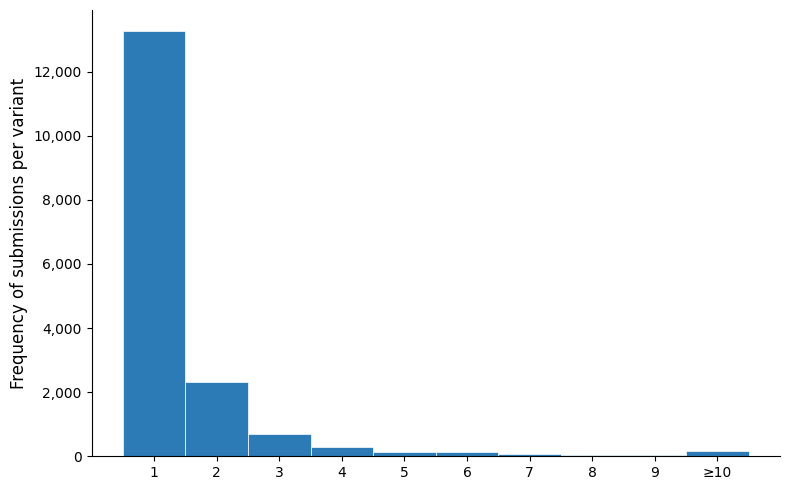

Total submissions: 25,986
Unique variants: 17,161
Mean submissions per variant: 1.51 (95% CI: 1.49–1.54)
Median submissions per variant: 1
Max submissions for a single variant: 37

Distribution of submissions per variant:
1     13259
2      2319
3       688
4       297
5       145
6       118
7        83
8        51
9        39
10       35
11       29
12       31
13       18
14       16
15       14
Variants with >10 submissions: 127 (0.7%)


In [ ]:
import pandas as pd

history = pd.read_csv("/content/cgn_submission_history.csv", low_memory=False)

# Submissions per variant
sub_counts = history.groupby("VariationID").size()
print(f"Total submissions: {len(history):,}")
print(f"Unique variants: {sub_counts.shape[0]:,}")
print(f"Mean submissions per variant: {sub_counts.mean():.2f}")
print(f"Median submissions per variant: {sub_counts.median():.0f}")
print(f"Max submissions for a single variant: {sub_counts.max()}")
print()
print("Distribution of submissions per variant:")
print(sub_counts.value_counts().sort_index().head(15).to_string())

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

cap = 10
capped = sub_counts.clip(upper=cap)
bins = np.arange(0.5, cap + 1.5, 1)

ax.hist(capped, bins=bins, color="#2c7bb6", edgecolor="white", linewidth=0.5)

ax.set_ylabel("Frequency of submissions per variant", fontsize=12)

ax.set_xticks(range(1, cap + 1))
ax.set_xticklabels([str(i) if i < cap else "≥10" for i in range(1, cap + 1)])

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/cgn_submissions_per_variant.png", dpi=300)
plt.show()

import pandas as pd
import numpy as np
from scipy import stats

history = pd.read_csv("/content/cgn_submission_history.csv", low_memory=False)

# Submissions per variant
sub_counts = history.groupby("VariationID").size()

# Mean and 95% CI via t-distribution
n = sub_counts.shape[0]
mean = sub_counts.mean()
se = stats.sem(sub_counts)
ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

print(f"Total submissions: {len(history):,}")
print(f"Unique variants: {n:,}")
print(f"Mean submissions per variant: {mean:.2f} (95% CI: {ci_low:.2f}–{ci_high:.2f})")
print(f"Median submissions per variant: {sub_counts.median():.0f}")
print(f"Max submissions for a single variant: {sub_counts.max()}")
print()
print("Distribution of submissions per variant:")
print(sub_counts.value_counts().sort_index().head(15).to_string())

over_10 = (sub_counts > 10).sum()
print(f"Variants with >10 submissions: {over_10:,} ({over_10 / sub_counts.shape[0] * 100:.1f}%)")

In [ ]:
import pandas as pd

history = pd.read_csv("/content/cgn_submission_history.csv", low_memory=False)

history["DateLastEvaluated"] = pd.to_datetime(
    history["DateLastEvaluated"],
    errors="coerce"
)

history["year"] = history["DateLastEvaluated"].dt.year

def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

clean = history.dropna(subset=["VariationID", "DateLastEvaluated", "year", "bucket"]).copy()

# Sort chronologically
clean = clean.sort_values(["VariationID", "DateLastEvaluated"])

years = range(int(clean["year"].min()), int(clean["year"].max()) + 1)

rows = []

for y in years:
    # Keep all submissions up to that year
    up_to_year = clean[clean["year"] <= y]

    # For each variant, keep latest known classification as of that year
    latest = (
        up_to_year
        .sort_values(["VariationID", "DateLastEvaluated"])
        .drop_duplicates("VariationID", keep="last")
    )

    counts = latest["bucket"].value_counts()

    rows.append({
        "year": y,
        "P": counts.get("P", 0),
        "LP": counts.get("LP", 0),
        "VUS": counts.get("VUS", 0),
        "LB": counts.get("LB", 0),
        "B": counts.get("B", 0),
        "total_unique_variants": latest["VariationID"].nunique()
    })

current_by_year = pd.DataFrame(rows).set_index("year")

print("Latest classification as of each year, one category per variant:")
print(current_by_year.to_string())

current_by_year.to_csv("/content/cgn_latest_classification_by_year.csv")
print("\nSaved: /content/cgn_latest_classification_by_year.csv")

Latest classification as of each year, one category per variant:
         P    LP   VUS    LB     B  total_unique_variants
year                                                     
1990     2     0     0     0     1                      3
1991     3     0     0     0     1                      4
1992    12     0     0     0     1                     13
1993    12     0     0     0     1                     13
1994    12     0     0     0     1                     13
1995    14     0     0     0     1                     15
1996    17     0     0     0     1                     18
1997    22     0     0     0     1                     23
1998    25     0     0     0     1                     26
1999    26     0     0     0     1                     27
2000    28     0     0     0     1                     29
2001    29     0     0     0     1                     30
2002    32     0     0     0     1                     33
2003    34     0     0     0     1                     35
2004   

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

# Use the reclassification-adjusted table:
# one latest classification per variant per year
try:
    trend_df = current_by_year.copy()
except NameError:
    trend_df = pd.read_csv(
        "/content/cgn_latest_classification_by_year.csv",
        index_col="year"
    )

# Make sure year is a normal column
trend_df = trend_df.reset_index()

# Standardize year column name if needed
if "index" in trend_df.columns and "year" not in trend_df.columns:
    trend_df = trend_df.rename(columns={"index": "year"})

# Restrict to modern ClinVar era
trend_df = trend_df[trend_df["year"] >= 2013].copy()

x = trend_df["year"].values

print(f"Year range: {trend_df['year'].min()}–{trend_df['year'].max()}\n")

for bucket in ["P", "LP", "VUS", "LB", "B"]:
    if bucket not in trend_df.columns:
        continue

    y = trend_df[bucket].values

    if y.max() == 0:
        continue

    # Linear fit
    slope_lin, intercept_lin, r_lin, _, _ = stats.linregress(x, y)
    r2_lin = r_lin ** 2

    # Exponential fit requires positive values
    mask = y > 0

    if mask.sum() < 3:
        print(f"{bucket}: not enough positive yearly values for exponential fit")
        print()
        continue

    log_y = np.log(y[mask])
    slope_exp, intercept_exp, r_exp, _, _ = stats.linregress(x[mask], log_y)
    r2_exp = r_exp ** 2

    better = "exponential" if r2_exp > r2_lin else "linear"

    growth_pct = (np.exp(slope_exp) - 1) * 100

    if slope_exp > 0:
        doubling = f"{np.log(2) / slope_exp:.3f} yrs"
    else:
        doubling = "not applicable"

    print(f"{bucket} [{better}]:")
    print(
        f"  Linear:      y = {slope_lin:.2f}x + ({intercept_lin:.2f})   "
        f"R² = {r2_lin:.4f}   slope = {slope_lin:+.1f} variants/yr"
    )
    print(
        f"  Exponential: y = e^({slope_exp:.4f}x + ({intercept_exp:.4f}))   "
        f"R² = {r2_exp:.4f}   growth = {growth_pct:+.1f}%/yr   "
        f"doubling = {doubling}"
    )
    print()

Year range: 2013–2026

P [exponential]:
  Linear:      y = 123.91x + (-249631.97)   R² = 0.9375   slope = +123.9 variants/yr
  Exponential: y = e^(0.2813x + (-562.2376))   R² = 0.9696   growth = +32.5%/yr   doubling = 2.464 yrs

LP [linear]:
  Linear:      y = 172.26x + (-347163.37)   R² = 0.8851   slope = +172.3 variants/yr
  Exponential: y = e^(0.5876x + (-1181.5743))   R² = 0.8690   growth = +80.0%/yr   doubling = 1.180 yrs

VUS [exponential]:
  Linear:      y = 483.19x + (-974011.05)   R² = 0.7866   slope = +483.2 variants/yr
  Exponential: y = e^(0.5393x + (-1083.0319))   R² = 0.9516   growth = +71.5%/yr   doubling = 1.285 yrs

LB [exponential]:
  Linear:      y = 470.70x + (-948828.64)   R² = 0.8271   slope = +470.7 variants/yr
  Exponential: y = e^(0.6821x + (-1372.0959))   R² = 0.8695   growth = +97.8%/yr   doubling = 1.016 yrs

B [linear]:
  Linear:      y = 118.71x + (-239075.00)   R² = 0.9317   slope = +118.7 variants/yr
  Exponential: y = e^(0.4952x + (-994.5922))   R² = 0.

# Reclassification rate

In [ ]:
import pandas as pd

dataset = "cgn"   # change to "cgn" if needed

history = pd.read_csv(f"/content/{dataset}_submission_history.csv", low_memory=False)
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")

def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    if "Pathogenic/Likely pathogenic" in s:
        return "P"
    if "Benign/Likely benign" in s:
        return "B"
    if "Uncertain" in s:
        return "VUS"
    if "Likely pathogenic" in s:
        return "LP"
    if "Likely benign" in s:
        return "LB"
    if "Pathogenic" in s:
        return "P"
    if "Benign" in s:
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

# Work only with submissions that have both a date and a clean bucket
dated = history.dropna(subset=["VariationID", "DateLastEvaluated", "bucket"]).copy()
dated = dated.sort_values(["VariationID", "DateLastEvaluated"])

# First-ever and most-recent submission per variant
first = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

# Combine first and latest classification
first_latest = (
    first[["VariationID", "DateLastEvaluated", "bucket"]]
    .rename(columns={
        "DateLastEvaluated": "first_date",
        "bucket": "first_bucket"
    })
    .merge(
        latest[["VariationID", "DateLastEvaluated", "bucket"]]
        .rename(columns={
            "DateLastEvaluated": "latest_date",
            "bucket": "latest_bucket"
        }),
        on="VariationID",
        how="inner"
    )
)

# Reclassification = first bucket differs from latest bucket
reclassified = first_latest[
    first_latest["first_bucket"] != first_latest["latest_bucket"]
].copy()

not_reclassified = first_latest[
    first_latest["first_bucket"] == first_latest["latest_bucket"]
].copy()

reclassified["transition"] = (
    reclassified["first_bucket"] + "_to_" + reclassified["latest_bucket"]
)

reclassified["years_to_reclassification"] = (
    reclassified["latest_date"] - reclassified["first_date"]
).dt.days / 365.25

# Report
print(f"Variants with ≥1 dated, clean-bucket submission: {len(first_latest):,}")
print(f"Reclassified first-to-latest:                    {len(reclassified):,}  ({len(reclassified) / len(first_latest) * 100:.1f}%)")
print(f"Not reclassified first-to-latest:                {len(not_reclassified):,}  ({len(not_reclassified) / len(first_latest) * 100:.1f}%)")

print("\nReclassification direction:")
print(reclassified["transition"].value_counts().to_string())

print("\nFirst bucket counts:")
print(first_latest["first_bucket"].value_counts().to_string())

print("\nLatest bucket counts:")
print(first_latest["latest_bucket"].value_counts().to_string())

# Transition matrix
transition_matrix = pd.crosstab(
    first_latest["first_bucket"],
    first_latest["latest_bucket"],
    rownames=["First bucket"],
    colnames=["Latest bucket"]
)

print("\nFirst-to-latest transition matrix:")
print(transition_matrix.to_string())

# Save outputs
reclassified.to_csv(f"/content/{dataset}_all_reclassified_first_to_latest.csv", index=False)
not_reclassified.to_csv(f"/content/{dataset}_not_reclassified_first_to_latest.csv", index=False)
transition_matrix.to_csv(f"/content/{dataset}_first_latest_transition_matrix.csv")

print(f"\nSaved:")
print(f"  /content/{dataset}_all_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_not_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_first_latest_transition_matrix.csv")

Variants with ≥1 dated, clean-bucket submission: 17,033
Reclassified first-to-latest:                    710  (4.2%)
Not reclassified first-to-latest:                16,323  (95.8%)

Reclassification direction:
transition
LP_to_P      196
P_to_LP      189
LB_to_B      186
B_to_LB       38
LB_to_VUS     30
VUS_to_LB     27
LP_to_VUS     16
VUS_to_LP     13
P_to_VUS       7
VUS_to_P       5
VUS_to_B       3

First bucket counts:
first_bucket
VUS    6337
LB     5776
LP     2167
P      1535
B      1218

Latest bucket counts:
latest_bucket
VUS    6342
LB     5625
LP     2157
P      1540
B      1369

First-to-latest transition matrix:
Latest bucket     B    LB    LP     P   VUS
First bucket                               
B              1180    38     0     0     0
LB              186  5560     0     0    30
LP                0     0  1955   196    16
P                 0     0   189  1339     7
VUS               3    27    13     5  6289

Saved:
  /content/cgn_all_reclassified_first_to_latest

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

dataset = "cgn"   # change to "cgn" if needed

# Load submission history
history = pd.read_csv(f"/content/{dataset}_submission_history.csv", low_memory=False)

# Parse dates
history["DateLastEvaluated"] = pd.to_datetime(
    history["DateLastEvaluated"],
    errors="coerce"
)

# Bucket ClinVar classifications into 5 groups
def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    if "Pathogenic/Likely pathogenic" in s:
        return "P"
    if "Benign/Likely benign" in s:
        return "B"
    if "Uncertain" in s:
        return "VUS"
    if "Likely pathogenic" in s:
        return "LP"
    if "Likely benign" in s:
        return "LB"
    if "Pathogenic" in s:
        return "P"
    if "Benign" in s:
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

# Keep only dated submissions with clean bucket labels
dated = history.dropna(
    subset=["VariationID", "DateLastEvaluated", "bucket"]
).copy()

dated = dated.sort_values(["VariationID", "DateLastEvaluated"])

# First and latest clean dated classification per variant
first = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

# Merge first and latest
first_latest = (
    first[["VariationID", "DateLastEvaluated", "bucket"]]
    .rename(columns={
        "DateLastEvaluated": "first_date",
        "bucket": "first_bucket"
    })
    .merge(
        latest[["VariationID", "DateLastEvaluated", "bucket"]]
        .rename(columns={
            "DateLastEvaluated": "latest_date",
            "bucket": "latest_bucket"
        }),
        on="VariationID",
        how="inner"
    )
)

# Reclassified variants only: first bucket differs from latest bucket
reclassified = first_latest[
    first_latest["first_bucket"] != first_latest["latest_bucket"]
].copy()

# Time to reclassification
reclassified["years_to_reclassification"] = (
    reclassified["latest_date"] - reclassified["first_date"]
).dt.days / 365.25

# Drop invalid/paradoxical intervals
reclassified = reclassified[
    reclassified["years_to_reclassification"] >= 0
].copy()

# Add transition label
reclassified["transition"] = (
    reclassified["first_bucket"] + "_to_" + reclassified["latest_bucket"]
)

# Mean and 95% CI function
def summarize_time(series):
    series = series.dropna()
    n = len(series)

    if n == 0:
        return pd.Series({
            "n": 0,
            "mean_years": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        })

    mean = series.mean()

    if n > 1:
        se = stats.sem(series)
        ci_low, ci_high = stats.t.interval(
            0.95,
            df=n - 1,
            loc=mean,
            scale=se
        )
    else:
        ci_low, ci_high = np.nan, np.nan

    return pd.Series({
        "n": n,
        "mean_years": mean,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

# Five key numbers: time to reclassification by starting category
summary = (
    reclassified
    .groupby("first_bucket")["years_to_reclassification"]
    .apply(summarize_time)
    .unstack()
    .reindex(["B", "LB", "VUS", "LP", "P"])
)

print(f"Total reclassified variants: {len(reclassified):,}")
print("\nMean time to reclassification by starting category:")
print(summary.round(2).to_string())

# Save simple outputs
reclassified.to_csv(
    f"/content/{dataset}_all_reclassified_first_to_latest.csv",
    index=False
)

summary.to_csv(
    f"/content/{dataset}_time_to_reclassification_by_starting_category.csv"
)

print(f"\nSaved:")
print(f"  /content/{dataset}_all_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_time_to_reclassification_by_starting_category.csv")

Total reclassified variants: 710

Mean time to reclassification by starting category:
                  n  mean_years  ci_low  ci_high
first_bucket                                    
B              38.0        5.16    4.22     6.11
LB            216.0        4.73    4.41     5.04
VUS            48.0        4.72    3.95     5.49
LP            212.0        3.96    3.56     4.35
P             196.0        4.04    3.37     4.71

Saved:
  /content/cgn_all_reclassified_first_to_latest.csv
  /content/cgn_time_to_reclassification_by_starting_category.csv


# NephVar Implementation

In [ ]:
gene_template = """<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>{gene} Variants — NephVar CGN</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;margin-bottom:24px;line-height:1.6}}
.controls{{display:flex;flex-wrap:wrap;gap:10px;align-items:center;margin-bottom:14px}}
input[type=text],select{{font-family:var(--sans);font-size:13px;padding:9px 12px;border:1px solid var(--line);
border-radius:4px;background:#fff;color:var(--ink)}}
input[type=text]{{flex:1;min-width:220px}}
.chk{{display:flex;align-items:center;gap:6px;font-family:var(--mono);font-size:12px;color:var(--soft);cursor:pointer}}
.count{{font-family:var(--mono);font-size:11px;color:var(--faint);margin-left:auto}}
table{{width:100%;border-collapse:collapse;font-size:13px;background:#fff;border:1px solid var(--line);border-radius:4px;overflow:hidden}}
th{{font-family:var(--mono);text-align:left;padding:11px 12px;background:#f6f5f1;font-weight:400;font-size:10.5px;
letter-spacing:.1em;text-transform:uppercase;color:var(--soft);cursor:pointer;white-space:nowrap}}
th:hover{{color:var(--ink)}}
td{{padding:9px 12px;border-top:1px solid var(--line)}}
tbody tr{{cursor:pointer}}tbody tr:hover td{{background:#f7f9fb}}
.mono{{font-family:var(--mono);font-size:11.5px}}
.pill{{font-family:var(--mono);display:inline-block;padding:2px 8px;border-radius:99px;font-size:10px;color:#fff}}
.arrow{{color:var(--faint);margin:0 4px}}
.flag{{font-family:var(--mono);font-size:10px;padding:1px 7px;border-radius:4px;background:#f0f3f6;color:var(--soft)}}
.flag.recl{{background:#fff3e0;color:#b25e00}}
.empty{{padding:40px;text-align:center;color:var(--faint)}}
.ovl{{position:fixed;inset:0;background:rgba(20,30,45,.45);display:none;align-items:flex-start;
justify-content:center;padding:40px 16px;overflow:auto;z-index:10}}
.modal{{background:#fff;border-radius:6px;max-width:680px;width:100%;padding:24px;box-shadow:0 20px 60px rgba(20,30,45,.3)}}
.modal h2{{font-family:var(--serif);margin:0 0 2px;font-size:24px}}
.modal .vid{{font-family:var(--mono);font-size:12px;color:var(--soft);margin-bottom:16px}}
.modal .vid a{{color:var(--accent);text-decoration:none}}.modal .vid a:hover{{text-decoration:underline}}
.grid{{display:grid;grid-template-columns:1fr 1fr;gap:8px 20px;font-size:13px;margin-bottom:18px}}
.grid div span{{color:var(--faint);display:block;font-family:var(--mono);font-size:10px;text-transform:uppercase;letter-spacing:.06em}}
.tl{{border-top:1px solid var(--line);padding-top:12px}}
.tl h3{{font-family:var(--mono);font-size:11px;text-transform:uppercase;letter-spacing:.08em;color:var(--soft);margin:0 0 8px}}
.tlrow{{display:grid;grid-template-columns:90px auto 1fr;gap:10px;align-items:center;padding:6px 0;
border-bottom:1px solid #f0f3f6;font-size:12.5px}}
.tlrow .d{{color:var(--faint);font-family:var(--mono)}}.tlrow .s{{color:var(--soft)}}
.x{{float:right;cursor:pointer;color:var(--faint);font-size:20px;line-height:1}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../../">NephVar</a> / <a href="../../">CGN</a> / <a href="../">Variants</a> / {gene}</div>
<h1>{gene} <em>Variants</em></h1>
<div class="sub">{n_total:,} unique ClinVar variants &middot; click any row for full classification
history and submission timeline.</div>

<div class="controls">
  <input id="q" type="text" placeholder="Search variant, protein change, or Variation ID…">
  <select id="cls"><option value="">All current classes</option>
    <option>Pathogenic</option><option>Likely pathogenic</option><option>Uncertain significance</option>
    <option>Likely benign</option><option>Benign</option><option>Conflicting</option>
  </select>
  <label class="chk"><input type="checkbox" id="recl"> Reclassified only</label>
  <span class="count" id="count"></span>
</div>
<table><thead><tr>
  <th data-k="VariationID">Var ID</th>
  <th data-k="protein_change">Protein change</th>
  <th data-k="first_class">First &rarr; Latest</th>
  <th data-k="current_class">Current</th>
  <th data-k="n_submitters">Submitters</th>
  <th data-k="n_submissions">Subs</th>
  <th data-k="first_year">First yr</th>
</tr></thead><tbody id="rows"></tbody></table>
<div id="empty" class="empty" style="display:none">No variants match your search.</div>
</div>
<div class="ovl" id="ovl"><div class="modal" id="modal"></div></div>
<script>
const DATA={data_json}, TL={tl_json};
const C={{P:'var(--P)',LP:'var(--LP)',VUS:'var(--VUS)',LB:'var(--LB)',B:'var(--B)'}};
const BK={{Pathogenic:'P','Likely pathogenic':'LP','Uncertain significance':'VUS','Likely benign':'LB',Benign:'B'}};
const pill=c=>c?`<span class="pill" style="background:${{C[c]||'#9aa6b2'}}">${{c}}</span>`:'';
let sortK='n_submitters',sortDir=-1;
function g(i){{return document.getElementById(i)}}
const q=g('q'),cls=g('cls'),recl=g('recl');
function isR(d){{return d.reclassified===true||d.reclassified==='True'}}
function render(){{
  let r=DATA.filter(d=>{{
    const t=(q.value||'').toLowerCase();
    const hit=!t||[d.Name,d.protein_change,d.VariationID].join(' ').toLowerCase().includes(t);
    return hit&&(!cls.value||String(d.current_class).includes(cls.value))&&(!recl.checked||isR(d));
  }});
  r.sort((a,b)=>{{let x=a[sortK],y=b[sortK];if(x!==''&&!isNaN(x)){{x=+x;y=+y}}return x>y?sortDir:x<y?-sortDir:0}});
  g('count').textContent=`${{r.length.toLocaleString()}} of ${{DATA.length.toLocaleString()}} variants`;
  g('empty').style.display=r.length?'none':'block';
  g('rows').innerHTML=r.map(d=>{{
    const t=d.first_class?(d.first_class===d.latest_class?pill(d.first_class):pill(d.first_class)+'<span class=arrow>&rarr;</span>'+pill(d.latest_class)):'<span style=color:#bcc6d0>&mdash;</span>';
    const fl=isR(d)?' <span class="flag recl">reclassified</span>':'';
    const cur=pill(BK[d.current_class])||'<span class=flag>'+(String(d.current_class).includes('Conflict')?'Conflicting':(d.current_class||'&mdash;'))+'</span>';
    return `<tr data-id="${{d.VariationID}}"><td class=mono>${{d.VariationID}}</td><td class=mono>${{d.protein_change||d.Name}}</td><td>${{t}}${{fl}}</td><td>${{cur}}</td><td class=mono>${{d.n_submitters}}</td><td class=mono>${{d.n_submissions}}</td><td class=mono>${{d.first_year||''}}</td></tr>`;
  }}).join('');
  document.querySelectorAll('#rows tr').forEach(tr=>tr.onclick=()=>openV(tr.dataset.id));
}}
function openV(id){{
  const d=DATA.find(x=>String(x.VariationID)===String(id));
  const tl=TL[id]||[];
  const meta=[['Variant type',d.variant_type],['Consequence',d.consequence],['Current class',d.current_class],
    ['Review status',d.review_status],['First &rarr; latest',(d.first_class||'&mdash;')+' &rarr; '+(d.latest_class||'&mdash;')],
    ['Submitters',d.n_submitters],['Submissions',d.n_submissions]];
  g('modal').innerHTML=`<span class=x onclick="closeV()">&times;</span>
    <h2>{gene} &middot; <span class=mono>${{d.protein_change||d.Name}}</span></h2>
    <div class=vid>Variation ID <a href="https://www.ncbi.nlm.nih.gov/clinvar/variation/${{d.VariationID}}/" target=_blank>${{d.VariationID}} &#8599;</a></div>
    <div class=grid>${{meta.map(m=>`<div><span>${{m[0]}}</span>${{m[1]||'&mdash;'}}</div>`).join('')}}</div>
    <div class=tl><h3>Submission timeline (${{tl.length}})</h3>${{tl.map(s=>`<div class=tlrow><span class=d>${{s.date}}</span><span>${{pill(s.b)||'<span class=flag>'+s.sig+'</span>'}}</span><span class=s>${{s.sub}}</span></div>`).join('')}}</div>`;
  g('ovl').style.display='flex';
}}
function closeV(){{g('ovl').style.display='none'}}
g('ovl').onclick=e=>{{if(e.target.id==='ovl')closeV()}};
document.addEventListener('keydown',e=>{{if(e.key==='Escape')closeV()}});
document.querySelectorAll('th').forEach(th=>th.onclick=()=>{{
  const k=th.dataset.k;if(sortK===k)sortDir*=-1;else{{sortK=k;sortDir=-1}}render();
}});
[q,cls,recl].forEach(el=>el.addEventListener('input',render));
render();
</script></body></html>"""

for gene in genes_list:
    gene_db = db[db["gene"] == gene]
    gene_records = gene_db.fillna("").to_dict(orient="records")
    gene_var_ids = set(gene_db["VariationID"].astype(int))
    gene_tl = {k: v for k, v in timelines.items() if k in gene_var_ids}

    html = gene_template.format(
        gene=gene,
        n_total=len(gene_db),
        data_json=json.dumps(gene_records),
        tl_json=json.dumps(gene_tl),
    )
    (out_dir / f"{gene}.html").write_text(html, encoding="utf-8")
    print(f"{gene:<8} {len(gene_records):>5} variants → {gene}.html")

C3        1751 variants → C3.html
CD46       553 variants → CD46.html
CFH       1498 variants → CFH.html
CFHR5      327 variants → CFHR5.html
CFI        770 variants → CFI.html
COL4A3    3153 variants → COL4A3.html
COL4A4    3448 variants → COL4A4.html
COL4A5    3089 variants → COL4A5.html
COL4A6     686 variants → COL4A6.html
FN1       1888 variants → FN1.html


In [ ]:
from pathlib import Path

out_dir = Path("/content/html/CGN/variants")
out_dir.mkdir(parents=True, exist_ok=True)

ACMG_COLORS = {"P":"var(--P)","LP":"var(--LP)","VUS":"var(--VUS)","LB":"var(--LB)","B":"var(--B)","Other":"var(--faint)"}

cards = ""
for gene in genes_list:
    pc = panel_counts[gene]
    boxes = "".join(
        f'<div class="acmgbox" style="background:{ACMG_COLORS[b]}">'
        f'<span class="acmgcount">{pc[b]}</span><span class="acmglabel">{b}</span></div>'
        for b in ACMG_ORDER
    )
    cards += f"""
    <a class="card" href="{gene}.html">
      <div class="card-head">
        <span class="gname">{gene}</span>
        <span class="gtotal">{pc['total']:,} variants</span>
      </div>
      <div class="acmgrow">{boxes}</div>
      <div class="cta">View variants &rarr;</div>
    </a>"""

html = f"""<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>CGN Variants — NephVar</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;max-width:680px;line-height:1.6;margin-bottom:40px}}
.grid{{display:grid;grid-template-columns:repeat(auto-fill,minmax(280px,1fr));gap:16px}}
.card{{display:block;text-decoration:none;color:inherit;background:#fff;border:1px solid var(--line);
border-radius:6px;padding:22px;transition:transform .14s ease,box-shadow .14s ease,border-color .14s ease}}
.card:hover{{transform:translateY(-2px);box-shadow:0 12px 28px rgba(20,30,45,.10);border-color:#cdd9e4}}
.card-head{{display:flex;align-items:baseline;justify-content:space-between;margin-bottom:14px}}
.gname{{font-family:var(--serif);font-size:28px}}
.gtotal{{font-family:var(--mono);font-size:11px;color:var(--faint)}}
.acmgrow{{display:flex;gap:5px;margin-bottom:14px}}
.acmgbox{{flex:1;border-radius:4px;color:#fff;padding:6px 4px;text-align:center}}
.acmgcount{{display:block;font-family:var(--mono);font-size:14px;font-weight:400}}
.acmglabel{{display:block;font-family:var(--mono);font-size:9px;letter-spacing:.06em;opacity:.9}}
.cta{{font-family:var(--mono);font-size:12px;color:var(--accent)}}
.legend{{display:flex;flex-wrap:wrap;gap:14px;margin-top:32px;font-family:var(--mono);font-size:10.5px;color:var(--soft)}}
.legend span{{display:inline-flex;align-items:center;gap:6px}}
.dot{{width:9px;height:9px;border-radius:99px;display:inline-block}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../">NephVar</a> / <a href="../">CGN</a> / Variants</div>
<h1>CGN <em>Variants</em></h1>
<div class="sub">ClinVar-derived variant database for the 10 chronic glomerulonephritis genes
(C3, CD46, CFH, CFHR5, CFI, COL4A3, COL4A4, COL4A5, COL4A6, FN1) &mdash; {len(db):,} unique variants
total. Select a gene to browse its full variant list with classification history and
submission timelines.</div>
<div class="grid">{cards}</div>
<div class="legend">
  <span><span class="dot" style="background:var(--P)"></span>Pathogenic (P)</span>
  <span><span class="dot" style="background:var(--LP)"></span>Likely pathogenic (LP)</span>
  <span><span class="dot" style="background:var(--VUS)"></span>Uncertain significance (VUS)</span>
  <span><span class="dot" style="background:var(--LB)"></span>Likely benign (LB)</span>
  <span><span class="dot" style="background:var(--B)"></span>Benign (B)</span>
  <span><span class="dot" style="background:var(--faint)"></span>Other / conflicting</span>
</div>
</div></body></html>"""

(out_dir / "index.html").write_text(html, encoding="utf-8")
print("Written: CGN/variants/index.html")

Written: CGN/variants/index.html


In [ ]:
gene_template = """<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>{gene} Variants — NephVar CGN</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;margin-bottom:24px;line-height:1.6}}
.controls{{display:flex;flex-wrap:wrap;gap:10px;align-items:center;margin-bottom:14px}}
input[type=text],select{{font-family:var(--sans);font-size:13px;padding:9px 12px;border:1px solid var(--line);
border-radius:4px;background:#fff;color:var(--ink)}}
input[type=text]{{flex:1;min-width:220px}}
.chk{{display:flex;align-items:center;gap:6px;font-family:var(--mono);font-size:12px;color:var(--soft);cursor:pointer}}
.count{{font-family:var(--mono);font-size:11px;color:var(--faint);margin-left:auto}}
table{{width:100%;border-collapse:collapse;font-size:13px;background:#fff;border:1px solid var(--line);border-radius:4px;overflow:hidden}}
th{{font-family:var(--mono);text-align:left;padding:11px 12px;background:#f6f5f1;font-weight:400;font-size:10.5px;
letter-spacing:.1em;text-transform:uppercase;color:var(--soft);cursor:pointer;white-space:nowrap}}
th:hover{{color:var(--ink)}}
td{{padding:9px 12px;border-top:1px solid var(--line)}}
tbody tr{{cursor:pointer}}tbody tr:hover td{{background:#f7f9fb}}
.mono{{font-family:var(--mono);font-size:11.5px}}
.pill{{font-family:var(--mono);display:inline-block;padding:2px 8px;border-radius:99px;font-size:10px;color:#fff}}
.arrow{{color:var(--faint);margin:0 4px}}
.flag{{font-family:var(--mono);font-size:10px;padding:1px 7px;border-radius:4px;background:#f0f3f6;color:var(--soft)}}
.flag.recl{{background:#fff3e0;color:#b25e00}}
.empty{{padding:40px;text-align:center;color:var(--faint)}}
.ovl{{position:fixed;inset:0;background:rgba(20,30,45,.45);display:none;align-items:flex-start;
justify-content:center;padding:40px 16px;overflow:auto;z-index:10}}
.modal{{background:#fff;border-radius:6px;max-width:680px;width:100%;padding:24px;box-shadow:0 20px 60px rgba(20,30,45,.3)}}
.modal h2{{font-family:var(--serif);margin:0 0 2px;font-size:24px}}
.modal .vid{{font-family:var(--mono);font-size:12px;color:var(--soft);margin-bottom:16px}}
.modal .vid a{{color:var(--accent);text-decoration:none}}.modal .vid a:hover{{text-decoration:underline}}
.grid{{display:grid;grid-template-columns:1fr 1fr;gap:8px 20px;font-size:13px;margin-bottom:18px}}
.grid div span{{color:var(--faint);display:block;font-family:var(--mono);font-size:10px;text-transform:uppercase;letter-spacing:.06em}}
.tl{{border-top:1px solid var(--line);padding-top:12px}}
.tl h3{{font-family:var(--mono);font-size:11px;text-transform:uppercase;letter-spacing:.08em;color:var(--soft);margin:0 0 8px}}
.tlrow{{display:grid;grid-template-columns:90px auto 1fr;gap:10px;align-items:center;padding:6px 0;
border-bottom:1px solid #f0f3f6;font-size:12.5px}}
.tlrow .d{{color:var(--faint);font-family:var(--mono)}}.tlrow .s{{color:var(--soft)}}
.x{{float:right;cursor:pointer;color:var(--faint);font-size:20px;line-height:1}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../../">NephVar</a> / <a href="../../">CGN</a> / <a href="../">Variants</a> / {gene}</div>
<h1>{gene} <em>Variants</em></h1>
<div class="sub">{n_total:,} unique ClinVar variants &middot; click any row for full classification
history and submission timeline.</div>

<div class="controls">
  <input id="q" type="text" placeholder="Search variant, protein change, or Variation ID…">
  <select id="cls"><option value="">All current classes</option>
    <option>Pathogenic</option><option>Likely pathogenic</option><option>Uncertain significance</option>
    <option>Likely benign</option><option>Benign</option><option>Conflicting</option>
  </select>
  <label class="chk"><input type="checkbox" id="recl"> Reclassified only</label>
  <span class="count" id="count"></span>
</div>
<table><thead><tr>
  <th data-k="VariationID">Var ID</th>
  <th data-k="protein_change">Protein change</th>
  <th data-k="first_class">First &rarr; Latest</th>
  <th data-k="current_class">Current</th>
  <th data-k="n_submitters">Submitters</th>
  <th data-k="n_submissions">Subs</th>
  <th data-k="first_year">First yr</th>
</tr></thead><tbody id="rows"></tbody></table>
<div id="empty" class="empty" style="display:none">No variants match your search.</div>
</div>
<div class="ovl" id="ovl"><div class="modal" id="modal"></div></div>
<script>
const DATA={data_json}, TL={tl_json};
const C={{P:'var(--P)',LP:'var(--LP)',VUS:'var(--VUS)',LB:'var(--LB)',B:'var(--B)'}};
const BK={{Pathogenic:'P','Likely pathogenic':'LP','Uncertain significance':'VUS','Likely benign':'LB',Benign:'B'}};
const pill=c=>c?`<span class="pill" style="background:${{C[c]||'#9aa6b2'}}">${{c}}</span>`:'';
let sortK='n_submitters',sortDir=-1;
function g(i){{return document.getElementById(i)}}
const q=g('q'),cls=g('cls'),recl=g('recl');
function isR(d){{return d.reclassified===true||d.reclassified==='True'}}
function render(){{
  let r=DATA.filter(d=>{{
    const t=(q.value||'').toLowerCase();
    const hit=!t||[d.Name,d.protein_change,d.VariationID].join(' ').toLowerCase().includes(t);
    return hit&&(!cls.value||String(d.current_class).includes(cls.value))&&(!recl.checked||isR(d));
  }});
  r.sort((a,b)=>{{let x=a[sortK],y=b[sortK];if(x!==''&&!isNaN(x)){{x=+x;y=+y}}return x>y?sortDir:x<y?-sortDir:0}});
  g('count').textContent=`${{r.length.toLocaleString()}} of ${{DATA.length.toLocaleString()}} variants`;
  g('empty').style.display=r.length?'none':'block';
  g('rows').innerHTML=r.map(d=>{{
    const t=d.first_class?(d.first_class===d.latest_class?pill(d.first_class):pill(d.first_class)+'<span class=arrow>&rarr;</span>'+pill(d.latest_class)):'<span style=color:#bcc6d0>&mdash;</span>';
    const fl=isR(d)?` <span class="flag recl">${{(d.direction||'').replace('toward_','&rarr; ')}}</span>`:'';
    const cur=pill(BK[d.current_class])||'<span class=flag>'+(String(d.current_class).includes('Conflict')?'Conflicting':(d.current_class||'&mdash;'))+'</span>';
    return `<tr data-id="${{d.VariationID}}"><td class=mono>${{d.VariationID}}</td><td class=mono>${{d.protein_change||d.Name}}</td><td>${{t}}${{fl}}</td><td>${{cur}}</td><td class=mono>${{d.n_submitters}}</td><td class=mono>${{d.n_submissions}}</td><td class=mono>${{d.first_year||''}}</td></tr>`;
  }}).join('');
  document.querySelectorAll('#rows tr').forEach(tr=>tr.onclick=()=>openV(tr.dataset.id));
}}
function openV(id){{
  const d=DATA.find(x=>String(x.VariationID)===String(id));
  const tl=TL[id]||[];
  const meta=[['Variant type',d.variant_type],['Consequence',d.consequence],['Current class',d.current_class],
    ['Review status',d.review_status],['First &rarr; latest',(d.first_class||'&mdash;')+' &rarr; '+(d.latest_class||'&mdash;')],
    ['Reclassified',isR(d)?('yes ('+(d.direction||'').replace('toward_','&rarr; ')+')'):'no'],
    ['Submitters',d.n_submitters],['Submissions',d.n_submissions]];
  g('modal').innerHTML=`<span class=x onclick="closeV()">&times;</span>
    <h2>{gene} &middot; <span class=mono>${{d.protein_change||d.Name}}</span></h2>
    <div class=vid>Variation ID <a href="https://www.ncbi.nlm.nih.gov/clinvar/variation/${{d.VariationID}}/" target=_blank>${{d.VariationID}} &#8599;</a></div>
    <div class=grid>${{meta.map(m=>`<div><span>${{m[0]}}</span>${{m[1]||'&mdash;'}}</div>`).join('')}}</div>
    <div class=tl><h3>Submission timeline (${{tl.length}})</h3>${{tl.map(s=>`<div class=tlrow><span class=d>${{s.date}}</span><span>${{pill(s.b)||'<span class=flag>'+s.sig+'</span>'}}</span><span class=s>${{s.sub}}</span></div>`).join('')}}</div>`;
  g('ovl').style.display='flex';
}}
function closeV(){{g('ovl').style.display='none'}}
g('ovl').onclick=e=>{{if(e.target.id==='ovl')closeV()}};
document.addEventListener('keydown',e=>{{if(e.key==='Escape')closeV()}});
document.querySelectorAll('th').forEach(th=>th.onclick=()=>{{
  const k=th.dataset.k;if(sortK===k)sortDir*=-1;else{{sortK=k;sortDir=-1}}render();
}});
[q,cls,recl].forEach(el=>el.addEventListener('input',render));
render();
</script></body></html>"""

for gene in genes_list:
    gene_db = db[db["gene"] == gene]
    gene_records = gene_db.fillna("").to_dict(orient="records")
    gene_var_ids = set(gene_db["VariationID"].astype(int))
    gene_tl = {k: v for k, v in timelines.items() if k in gene_var_ids}

    html = gene_template.format(
        gene=gene,
        n_total=len(gene_db),
        data_json=json.dumps(gene_records),
        tl_json=json.dumps(gene_tl),
    )
    (out_dir / f"{gene}.html").write_text(html, encoding="utf-8")
    print(f"{gene:<8} {len(gene_records):>5} variants → {gene}.html")

C3        1751 variants → C3.html
CD46       553 variants → CD46.html
CFH       1498 variants → CFH.html
CFHR5      327 variants → CFHR5.html
CFI        770 variants → CFI.html
COL4A3    3153 variants → COL4A3.html
COL4A4    3448 variants → COL4A4.html
COL4A5    3089 variants → COL4A5.html
COL4A6     686 variants → COL4A6.html
FN1       1888 variants → FN1.html


In [ ]:
import zipfile

zip_path = Path("/content/cgn_variants.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(out_dir.glob("*.html")):
        zf.write(f, arcname=f"variants/{f.name}")
    for f in glob.glob("/content/cgn_*.csv") + glob.glob("/content/cgn_db_*.csv"):
        zf.write(f, arcname=f"data/{Path(f).name}")

print(f"{zip_path.name}: {sum(1 for _ in out_dir.glob('*.html'))} HTML pages "
      f"({zip_path.stat().st_size/1024:.1f} KB)")

from google.colab import files
files.download(str(zip_path))

cgn_variants.zip: 11 HTML pages (5048.6 KB)


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/cgn_db_conflicting.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/cgn_db_reclassified_all.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/cgn_db_by_submitters.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>